In [ ]:
!pip install gdown nltk scikit-learn pandas matplotlib seaborn spacy --quiet
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import gdown
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [ ]:
file_id = "1bdVaNqx3rqyfX81zcO-DLnifFg9TB2an"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv", encoding='latin1')

print("Columns:", df.columns)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1bdVaNqx3rqyfX81zcO-DLnifFg9TB2an
To: /content/dataset.csv
100%|██████████| 66.2M/66.2M [00:00<00:00, 68.5MB/s]


Columns: Index(['review', 'sentiment'], dtype='object')


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
text_col, label_col = None, None

for col in df.columns:
    if df[col].dtype == 'object' and text_col is None:
        text_col = col
    if df[col].nunique() < 20 and label_col is None:
        label_col = col

df = df[[text_col, label_col]].dropna()
df.columns = ['review', 'sentiment']

print("Using:", text_col, "as text")
print("Using:", label_col, "as label")

Using: review as text
Using: sentiment as label


In [ ]:
if df['sentiment'].dtype != 'object':
    df['sentiment'] = df['sentiment'].astype(str)

/tmp/ipykernel_4218/1998005035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['sentiment'], palette="coolwarm")


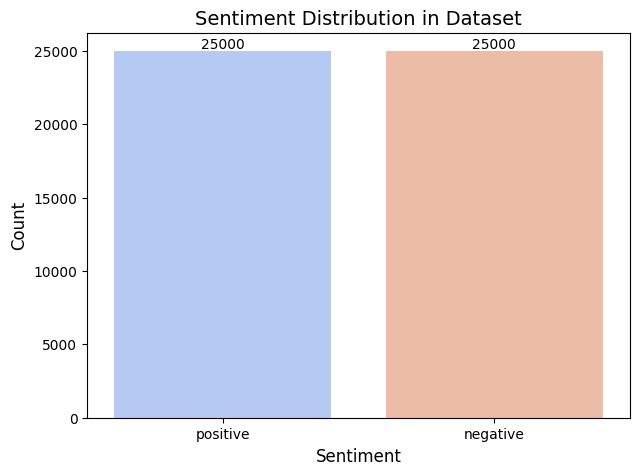

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x=df['sentiment'], palette="coolwarm")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Sentiment Distribution in Dataset", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

In [ ]:
nltk.download('stopwords', quiet=True)
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    doc = nlp(text)

    tokens = [
        token.lemma_ for token in doc
        if token.text not in stop_words and token.is_alpha
    ]

    return " ".join(tokens)

print("Preprocessing...")
df['clean'] = df['review'].apply(preprocess)

Preprocessing...


In [ ]:
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean'])

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean'])

y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [ ]:
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=300), param_grid, cv=3)
grid.fit(X_train, y_train)

lr = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'C': 1, 'solver': 'liblinear'}


In [ ]:
svm = LinearSVC()
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate("Naive Bayes", y_test, pred_nb)

pred_lr = lr.predict(X_test)
evaluate("Logistic Regression", y_test, pred_lr)
evaluate("SVM", y_test, pred_svm)


Naive Bayes
Accuracy: 0.8606
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      4961
    positive       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Logistic Regression
Accuracy: 0.8955
              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4961
    positive       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


SVM
Accuracy: 0.887
              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      

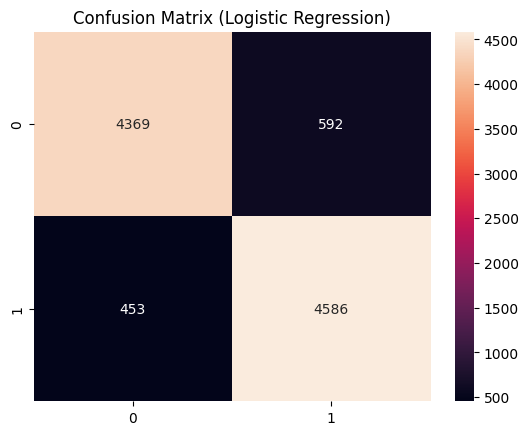

In [ ]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

In [ ]:
sample_reviews = [
    "I absolutely loved this movie, it was fantastic!",
    "This was the worst product I have ever used",
    "The experience was okay, not great but not bad",
    "Amazing performance and great acting",
    "I hate this, very disappointing"
]

print("\n===== SENTIMENT ANALYSIS OUTPUT =====\n")

for review in sample_reviews:
    clean_text = preprocess(review)
    vec = tfidf.transform([clean_text])

    pred = lr.predict(vec)[0]
    prob = np.max(lr.predict_proba(vec))

    print(f"Review: {review}")
    print(f"Predicted Sentiment: {pred}")
    print(f"Confidence: {round(prob, 2)}")
    print("-" * 60)


===== SENTIMENT ANALYSIS OUTPUT =====

Review: I absolutely loved this movie, it was fantastic!
Predicted Sentiment: positive
Confidence: 0.99
------------------------------------------------------------
Review: This was the worst product I have ever used
Predicted Sentiment: negative
Confidence: 0.96
------------------------------------------------------------
Review: The experience was okay, not great but not bad
Predicted Sentiment: negative
Confidence: 0.76
------------------------------------------------------------
Review: Amazing performance and great acting
Predicted Sentiment: positive
Confidence: 0.99
------------------------------------------------------------
Review: I hate this, very disappointing
Predicted Sentiment: negative
Confidence: 0.96
------------------------------------------------------------


In [ ]:
def chatbot(user_input):
    text = user_input.lower()

    if "nlp" in text:
        return """Natural Language Processing (NLP) is a branch of Artificial Intelligence that focuses on enabling machines to understand, interpret, and generate human language.
It combines linguistics, computer science, and machine learning to process text and speech data.
Applications include chatbots, machine translation, sentiment analysis, and voice assistants like Alexa and Siri."""


    elif "tf idf" in text or "tfidf" in text or "tdf if" in text:
        return """TF-IDF (Term Frequency–Inverse Document Frequency) is a numerical statistic used to evaluate how important a word is in a document relative to a corpus.
Term Frequency (TF) measures how often a word appears in a document, while Inverse Document Frequency (IDF) reduces the weight of frequently occurring words across documents.
It is widely used in search engines, document ranking, and text classification tasks."""


    elif "tokenization" in text:
        return """Tokenization is the process of splitting text into smaller units called tokens, such as words or sentences.
For example, the sentence 'I love NLP' becomes ['I', 'love', 'NLP'].
It is a crucial first step in NLP pipelines, enabling further analysis like parsing, tagging, and feature extraction."""


    elif "stemming" in text or "lemmatization" in text:
        return """Stemming and Lemmatization are techniques used to reduce words to their base or root form.
Stemming removes suffixes in a crude way (e.g., 'playing' → 'play'), while Lemmatization uses linguistic rules and dictionaries to obtain the correct base form (e.g., 'better' → 'good').
Lemmatization is more accurate but computationally more expensive."""


    elif "bag of words" in text or "bow" in text:
        return """Bag of Words (BoW) is a feature extraction method used in NLP to convert text into numerical vectors.
It represents text by counting the frequency of each word without considering grammar or word order.
Although simple and efficient, it ignores context and semantics, which can limit performance in complex tasks."""


    elif "ner" in text or "named entity" in text:
        return """Named Entity Recognition (NER) is an NLP technique used to identify and classify entities in text into predefined categories such as person names, organizations, locations, dates, and more.
For example, in 'Elon Musk founded SpaceX', 'Elon Musk' is identified as a person and 'SpaceX' as an organization.
NER is widely used in information extraction and search systems."""


    elif "ai application" in text or "applications of ai" in text:
        return """Artificial Intelligence is widely used in various real-world applications:
1. Healthcare – disease prediction, medical imaging analysis
2. Finance – fraud detection and risk analysis
3. E-commerce – recommendation systems (Amazon, Flipkart)
4. Autonomous vehicles – self-driving cars
5. Chatbots and virtual assistants – Siri, Alexa, Google Assistant"""


    elif "ai" in text:
        return """Artificial Intelligence (AI) is the simulation of human intelligence in machines.
It enables systems to learn from data, make decisions, and solve problems.
Key domains include Machine Learning, NLP, Computer Vision, and Robotics."""

    negative_phrases = [
        "not good", "not well", "not fine", "not okay",
        "not able", "not happy", "not satisfied",
        "not upto the mark", "not up to the mark",
        "worst", "bad", "terrible", "awful",
        "sad", "tired", "sick", "ill",
        "hate", "problem", "issue", "pain",
        "boring", "disappointing"
    ]

    for phrase in negative_phrases:
        if phrase in text:
            return "Sentiment Analysis Result: negative (rule-based detection)"

    if "not" in text:
        return "Sentiment Analysis Result: negative (negation detected)"


    processed = preprocess(user_input)
    vec = tfidf.transform([processed])

    probs = lr.predict_proba(vec)
    confidence = np.max(probs)
    pred = lr.predict(vec)[0]

    if confidence < 0.55:
        return """I couldn't clearly understand the query.
Try asking about NLP concepts or express your sentence more clearly."""

    return f"Sentiment Analysis Result: {pred} (confidence: {round(confidence,2)})"

In [ ]:
test_inputs = [
    "What is NLP?",
    "Explain AI applications",
    "I love this product",
    "This is the worst experience ever",
    "asdfghjkl"
]

for text in test_inputs:
    print(f"\nUser: {text}")
    print("Bot:", chatbot(text))


User: What is NLP?
Bot: Natural Language Processing (NLP) is a branch of Artificial Intelligence that focuses on enabling machines to understand, interpret, and generate human language.
It combines linguistics, computer science, and machine learning to process text and speech data.
Applications include chatbots, machine translation, sentiment analysis, and voice assistants like Alexa and Siri.

User: Explain AI applications
Bot: Artificial Intelligence is widely used in various real-world applications:
1. Healthcare – disease prediction, medical imaging analysis
2. Finance – fraud detection and risk analysis
3. E-commerce – recommendation systems (Amazon, Flipkart)
4. Autonomous vehicles – self-driving cars
5. Chatbots and virtual assistants – Siri, Alexa, Google Assistant

User: I love this product
Bot: Sentiment Analysis Result: positive (confidence: 0.81)

User: This is the worst experience ever
Bot: Sentiment Analysis Result: negative (rule-based detection)

User: asdfghjkl
Bot: I

In [ ]:
while True:
    user = input("You: ")
    if user.lower() == "exit":
        break
    print("Bot:", chatbot(user))

You: I am not well
Bot: Sentiment Analysis Result: negative (rule-based detection)
You: He is fine
Bot: Sentiment Analysis Result: positive (confidence: 0.89)
You: noice
Bot: I couldn't clearly understand the query.
Try asking about NLP concepts or express your sentence more clearly.
You: explain ifidf
Bot: Artificial Intelligence (AI) is the simulation of human intelligence in machines.
It enables systems to learn from data, make decisions, and solve problems.
Key domains include Machine Learning, NLP, Computer Vision, and Robotics.
You: exit
